In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns    

load dataset

In [2]:
df = pd.read_csv("./Global_Pollution_Analysis.csv")
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


##### Handle missing value

In [3]:
df.isnull().sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

since no null values in dataset. therefore no need of imputation or removal techniques

##### Standard scaling on Pollution Indices

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pollution_indices_cols = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']

df[pollution_indices_cols] = scaler.fit_transform(df[pollution_indices_cols])

In [5]:
df[pollution_indices_cols].head()

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index
0,1.376167,0.193880,-0.619764
1,-1.403578,-1.153098,1.028744
2,-1.330788,-0.668076,1.142400
3,1.494394,-1.009403,0.431675
4,-0.021926,0.262567,1.138106


##### Encoding categorical Features

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    str    
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float64
 11  Popu

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Country'] = encoder.fit_transform(df["Country"])

In [12]:
yearly_trends = df.groupby('Year')[[
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'Energy_Recovered (in GWh)'
]].mean()

yearly_trends.head()

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Energy_Recovered (in GWh)
Year,,,,
2000,0.256617,0.072583,-0.181989,296.889000
2001,-0.637654,-0.655996,-0.130036,288.877778
2002,-0.089162,0.180136,-0.028892,259.750769
2003,0.335938,0.379503,0.611174,208.139000
2004,-0.142082,0.119064,-0.164913,186.458182


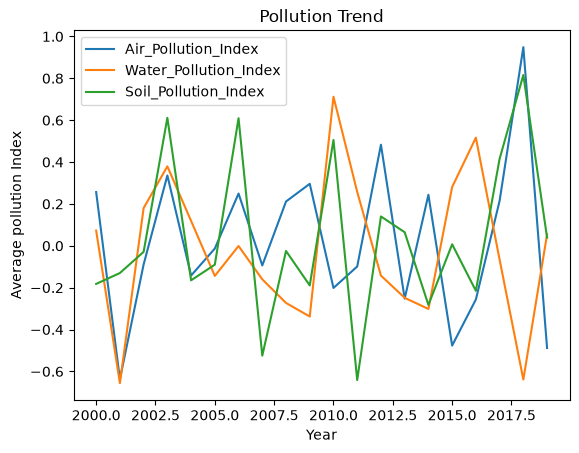

In [13]:
yearly_trends[["Air_Pollution_Index", "Water_Pollution_Index","Soil_Pollution_Index"]].plot()

plt.title("Pollution Trend")
plt.xlabel("Year")
plt.ylabel("Average pollution Index")
plt.show()

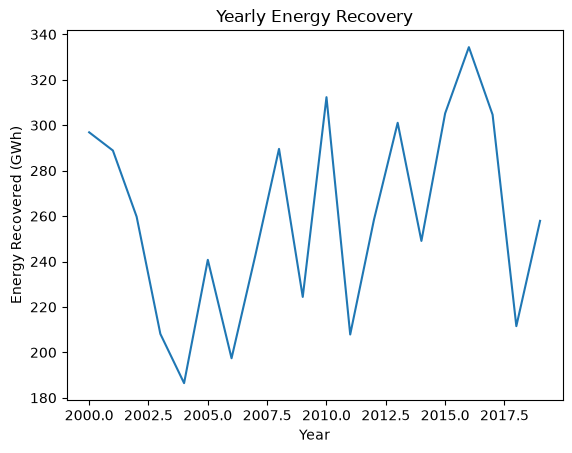

In [14]:
yearly_trends['Energy_Recovered (in GWh)'].plot()

plt.title('Yearly Energy Recovery')
plt.xlabel('Year')
plt.ylabel('Energy Recovered (GWh)')
plt.show()

##### K-Means clustering

In [15]:
from sklearn.cluster import KMeans

features = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Energy_Recovered (in GWh)"
]

X = df[features]

In [22]:
kmeans = KMeans(n_clusters=5, random_state=42)

df["Cluster"] = kmeans.fit_predict(X)

In [23]:
df[['Country', 'Cluster']].head(20)

,Country,Cluster
0,77,0
1,147,2
2,136,2
3,38,0
4,46,3
5,41,0
6,37,0
7,31,2
8,156,2
9,153,2


In [24]:
df['Cluster'].value_counts()

Cluster
3    55
2    40
0    38
4    37
1    30
Name: count, dtype: int64

##### Elbow method

In [25]:
elbow = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    elbow.append(kmeans.inertia_)

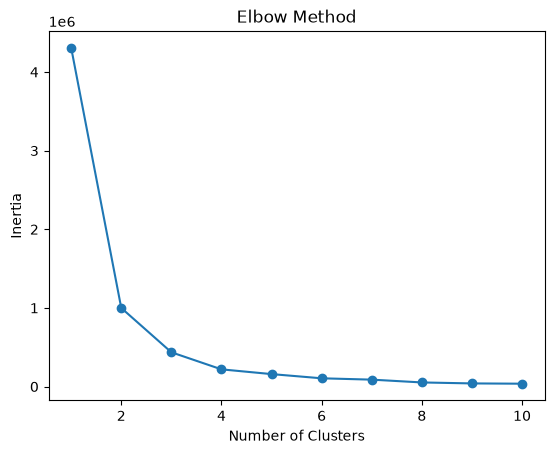

In [26]:
plt.plot(range(1, 11), elbow, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

- the elbow appears at 3, then use

In [27]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

In [28]:
cluster = df.groupby('Cluster')[[
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'Energy_Recovered (in GWh)'
]].mean()

cluster.head()

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Energy_Recovered (in GWh)
Cluster,,,,
0,-0.007332,-0.028474,-0.096356,94.079028
1,-0.021005,0.104524,0.122942,282.812754
2,0.033513,-0.087492,-0.026192,437.321525


In [70]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

kmeans_means = df.groupby('Cluster')['Energy_Recovered (in GWh)'].mean()

df['KMeans_Prediction'] = df['Cluster'].map(kmeans_means)


In [71]:
kmeans_r2 = r2_score(
    df['Energy_Recovered (in GWh)'],
    df['KMeans_Prediction']
)

kmeans_mse = mean_squared_error(
    df['Energy_Recovered (in GWh)'],
    df['KMeans_Prediction']
)

kmeans_mae = mean_absolute_error(
    df['Energy_Recovered (in GWh)'],
    df['KMeans_Prediction']
)

In [74]:
print("R²:", kmeans_r2)
print("MSE:", kmeans_mse)
print("MAE:", kmeans_mae)

R²: 0.8989546626091339
MSE: 2176.7683478573394
MAE: 39.480460002661104


### Bar plot of cluster(pollution)

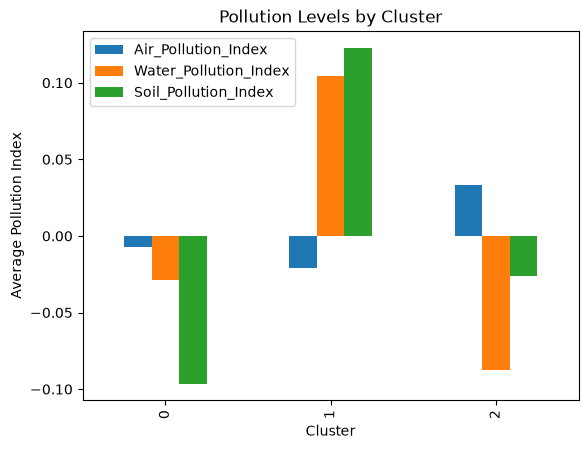

In [29]:
cluster[[
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index'
]].plot(kind='bar')

plt.title('Pollution Levels by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Pollution Index')
plt.show()

### Bar plot on cluster (Energy)

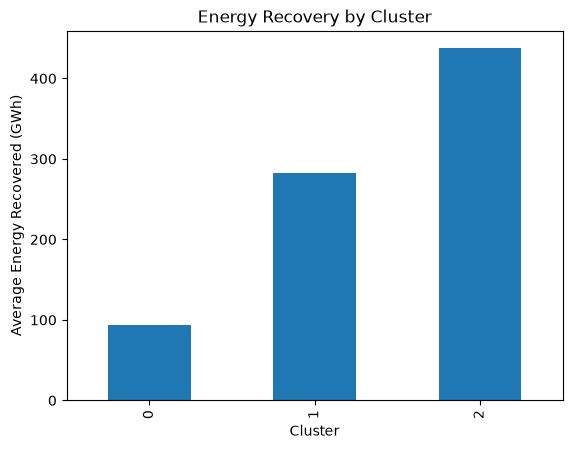

In [30]:
cluster['Energy_Recovered (in GWh)'].plot(kind='bar')

plt.title('Energy Recovery by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Energy Recovered (GWh)')
plt.show()

#### hierarchical clustering

In [34]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=3)

df["Hierarchical_Cluster"] = model.fit_predict(X)

In [35]:
df[["Country", "Hierarchical_Cluster"]].head(20)

,Country,Hierarchical_Cluster
0,77,0
1,147,2
2,136,2
3,38,0
4,46,0
5,41,0
6,37,0
7,31,2
8,156,2
9,153,2


#### Dendogram

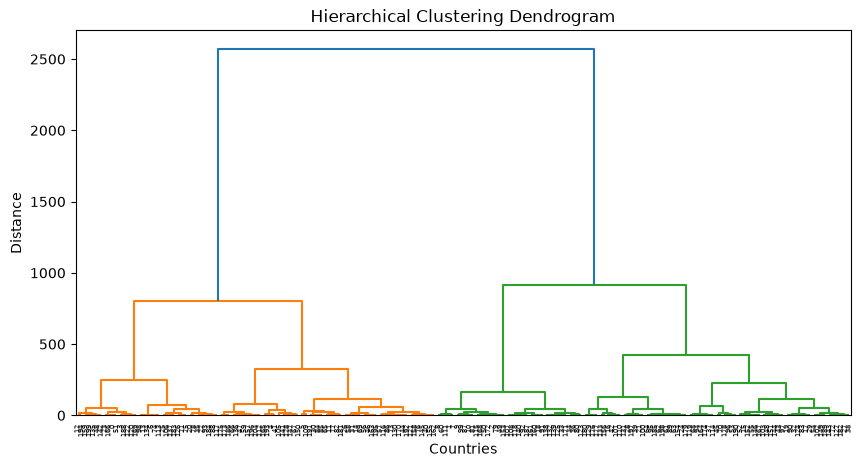

In [36]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X, method='ward')

plt.figure(figsize=(10, 5))

dendrogram(linked)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Countries')
plt.ylabel('Distance')
plt.show()

#### Comparing kmeans and Hierarchical Cluster

In [37]:
print("K-Means Clusters:")
print(df['Cluster'].value_counts())

print("\nHierarchical Clusters:")
print(df['Hierarchical_Cluster'].value_counts())

K-Means Clusters:
Cluster
0    72
1    69
2    59
Name: count, dtype: int64

Hierarchical Clusters:
Hierarchical_Cluster
0    93
1    69
2    38
Name: count, dtype: int64


In [38]:
compare = pd.crosstab(
    df['Cluster'],
    df['Hierarchical_Cluster']
)

print(compare)

Hierarchical_Cluster   0   1   2
Cluster                         
0                     72   0   0
1                     21  48   0
2                      0  21  38


In [72]:
hierarchical_means = df.groupby('Hierarchical_Cluster')['Energy_Recovered (in GWh)'].mean()

df['Hierarchical_Prediction'] = df['Hierarchical_Cluster'].map(hierarchical_means)

In [73]:
hier_r2 = r2_score(
    df['Energy_Recovered (in GWh)'],
    df['Hierarchical_Prediction']
)

hier_mse = mean_squared_error(
    df['Energy_Recovered (in GWh)'],
    df['Hierarchical_Prediction']
)

hier_mae = mean_absolute_error(
    df['Energy_Recovered (in GWh)'],
    df['Hierarchical_Prediction']
)

In [75]:
print("R²:", hier_r2)
print("MSE:", hier_mse)
print("MAE:", hier_mae)

R²: 0.8649902987789605
MSE: 2908.445375711129
MAE: 43.66936478679167


In [39]:
df.columns

Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)', 'Cluster', 'Hierarchical_Cluster'],
      dtype='str')

In [54]:
features_nn = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Industrial_Waste (in tons)",
    "CO2_Emissions (in MT)",
    "Energy_Consumption_Per_Capita (in MWh)"
]

X = df[features_nn]
y = df["Energy_Recovered (in GWh)"]

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [57]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(16, input_shape=(X_train.shape[1],)),
    keras.layers.Dense(8),
    keras.layers.Dense(1)
])

d:\Coding\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [59]:
hist = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 94872.0000 - mae: 272.4620 - val_loss: 77338.1875 - val_mae: 238.6420
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 94830.9219 - mae: 272.3947 - val_loss: 77309.6172 - val_mae: 238.5778
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 94789.0859 - mae: 272.3250 - val_loss: 77279.9844 - val_mae: 238.5107
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 94749.2500 - mae: 272.2578 - val_loss: 77249.1797 - val_mae: 238.4398
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 94708.1719 - mae: 272.1867 - val_loss: 77216.8125 - val_mae: 238.3668
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 94664.7969 - mae: 272.1137 - val_loss: 77183.0625 - val_mae: 238.2911
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 94619.0547 - mae: 272.0375 - val_loss: 77148.6250 - val_mae: 238.2097
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 94572.1094 - mae: 271.9555 - val_loss: 77109.3359 - val_mae: 238.1209
Ep

In [60]:
loss, mae = model.evaluate(X_test, y_test)

print("MAE", mae)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 64257.4883 - mae: 202.7516
MAE 202.75155639648438


In [61]:
predictions = model.predict(X_test)

print(predictions[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[12.208845]
 [56.810894]
 [71.82956 ]
 [43.32938 ]
 [20.996576]]


In [62]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

In [63]:
print("R² Score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

R² Score: -1.6572184175030706
Mean Squared Error: 64257.484396697255
Mean Absolute Error: 202.75156312036515


In [64]:
def create_model (neurons=16, learning_rate=0.001):
    model = keras.Sequential([
        keras.layers.Dense(neurons, activation='relu',
                           input_shape = (X_train.shape[1],)),
        keras.layers.Dense(8, activation="relu"),
        keras.layers.Dense(1)
    ])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer = optimizer,
        loss='mse',
        metrics = ["mae"]
    )

    return model

In [65]:
neurons_list = [8, 16, 32]
learning_rates = [0.001, 0.01]

best_model = None
best_mae = float('inf')

for neurons in neurons_list:
    for learning_rate in learning_rates:
        
        model = create_model(neurons, learning_rate)
        
        model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=16,
            verbose=0
        )
        
        predictions = model.predict(X_test, verbose=0).flatten()
        
        mae = mean_absolute_error(y_test, predictions)
        
        print("Neurons:", neurons,
              "Learning Rate:", learning_rate,
              "MAE:", mae)
        
        if mae < best_mae:
            best_mae = mae
            best_model = model

d:\Coding\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neurons: 8 Learning Rate: 0.001 MAE: 201.30409889507294


d:\Coding\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neurons: 8 Learning Rate: 0.01 MAE: 135.84097718811034


d:\Coding\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Neurons: 16 Learning Rate: 0.01 MAE: 137.16347694396973


d:\Coding\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neurons: 32 Learning Rate: 0.001 MAE: 164.97114966201784


d:\Coding\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neurons: 32 Learning Rate: 0.01 MAE: 134.2343620300293


In [66]:
nn_predictions = best_model.predict(X_test, verbose=0).flatten()

nn_r2 = r2_score(y_test, nn_predictions)
nn_mse = mean_squared_error(y_test, nn_predictions)
nn_mae = mean_absolute_error(y_test, nn_predictions)

print("Neural Network Results")
print("R²:", nn_r2)
print("MSE:", nn_mse)
print("MAE:", nn_mae)

Neural Network Results
R²: 0.020820913845897238
MSE: 23678.740308161672
MAE: 134.2343620300293


In [67]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [68]:
linear_r2 = r2_score(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_mae = mean_absolute_error(y_test, linear_predictions)

print("Linear Regression Results")
print("R²:", linear_r2)
print("MSE:", linear_mse)
print("MAE:", linear_mae)

Linear Regression Results
R²: -0.029508522087082767
MSE: 24895.81863445033
MAE: 141.83851507883617


In [69]:
print("Model Comparison")

print("\nNeural Network")
print("R²:", nn_r2)
print("MSE:", nn_mse)
print("MAE:", nn_mae)

print("\nLinear Regression")
print("R²:", linear_r2)
print("MSE:", linear_mse)
print("MAE:", linear_mae)

Model Comparison

Neural Network
R²: 0.020820913845897238
MSE: 23678.740308161672
MAE: 134.2343620300293

Linear Regression
R²: -0.029508522087082767
MSE: 24895.81863445033
MAE: 141.83851507883617


In [77]:
results = pd.DataFrame({
    'Model': [
        'K-Means',
        'Hierarchical Clustering',
        'Neural Network'
    ],
    'R2': [
        kmeans_r2,
        hier_r2,
        nn_r2
    ],
    'MSE': [
        kmeans_mse,
        hier_mse,
        nn_mse
    ],
    'MAE': [
        kmeans_mae,
        hier_mae,
        nn_mae
    ]
})

results

,Model,R2,MSE,MAE
0,K-Means,0.898955,2176.768348,39.480460
1,Hierarchical Clustering,0.864990,2908.445376,43.669365
2,Neural Network,0.020821,23678.740308,134.234362
